In [133]:
# 本实验采用echo state network (ESN) 
# 1. 单任务：仅预测 Mackey–Glass 序列
# 训练集是一条 Mackey–Glass 轨道的后半段（前 T_washout 步只用来把 reservoir“热身”，不参与拟合）；
# 2. 多任务：同时预测 Mackey–Glass 序列和一个正弦波到方波的转换序列 （测试Neuromorphic hierarchical modular reservoirs Milisa et al.,2025）
# 训练集是 Mackey–Glass 轨道的后半段 + 正弦波到方波转换序列的后半段

# 对每个时间步 t，用当前值 x_t 驱动 reservoir、读出层去预测下一步 x_{t+1}。 
# 读出层使用岭回归训练。
# 测试时，使用前 HORIZON 步的真实数据驱动 reservoir，然后让读出层连续预测后续 HORIZON 步的数据。
# 评估指标是预测的 NRMSE（归一化均方根误差）（取自Jaeger 2004）
# 可视化结果展示不同拓扑结构、不同谱半径下的预测性能，并验证混沌边缘现象。

import numpy as np
import matplotlib.pyplot as plt
import networkx as nx # networkx 是一个用于创建和操作复杂网络的Python库
import seaborn as sns
import scienceplots
import matplotlib.ticker as mticker


plt.style.use(["science", "no-latex", "grid"])  # 主风格
sns.set_palette("deep")                        
sns.set_context("notebook")                    
plt.rcParams["figure.figsize"] = (7.2, 4.2)
plt.rcParams["figure.dpi"] = 120           

实验参数

In [ ]:
# 参数
# 输入层和输出层均为1维 因为Mackey-Glass序列是一维时间序列
N = 640 # reservoir规模 # 神经元数量
k_target = 6 # 平均连接数 调控稀疏度
W_in_scale = 0.1 # 输入权重缩放 控制输入强度
# 不同的谱半径列表 谱半径 ρ (spectral radius) 是矩阵特征值的最大模值，反映了系统动力学的稳定性和记忆能力
# 谱半径过小，系统动力学过于平稳，记忆能力差；谱半径过大，系统动力学可能变得混沌，不稳定。
# 一般来说，谱半径在接近1时，系统具有较好的记忆能力和平衡的动力学特性，适合处理时间序列数据，但具体选择还需根据任务需求进行调整。
RHO_list = [ 0.6, 0.7,0.8, 0.9, 0.95, 1.0, 1.05, 1.1, 1.2, 1.3, 1.5] 
N_seed = 10 # 不同的随机种子数 即每个条件重复几次

T_train = 2000 # 训练时间步长 
T_test = 2000 # 测试时间步长 
T_washout = 200 # 洗牌时间步长 # 用于消除初始状态的影响
HORIZON = 84      # Mackey glass的自由预测步数 (Mackey-Glass 经典标准是 84)(取自Wringe et al., 2024)
REG = 1e-6          # 岭回归正则化系数 (Ridge Regression Lambda)
# 默认情况下只跑单任务 多任务暂时搁置
MULTI_TASK = False   # False: 只跑 MG 单任务 
                     # True : 在所有拓扑上跑 MG + 正弦->方波 多任务 这时候reservoir规模N必须能被8整除

1. 实验数据生成

任务数据1：MG 序列 / Mackey–Glass 序列 是一个具有复杂非线性和混沌特性的标量时间序列，常被用来测试时间序列预测性能

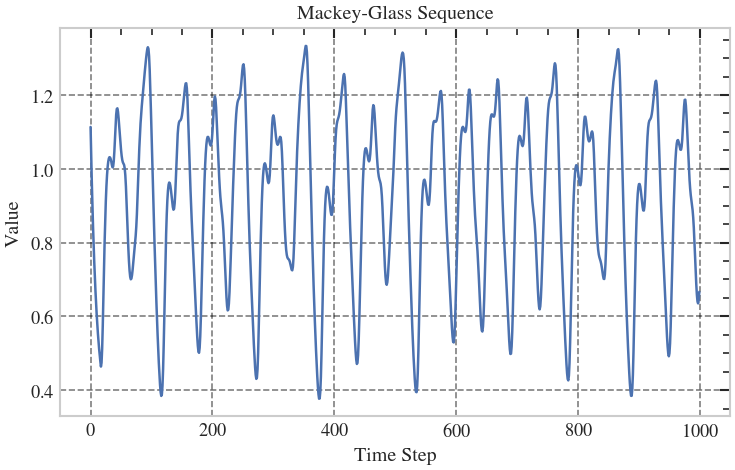

In [135]:
# 生成 Mackey-Glass 时间序列的函数
def generate_mackey_glass(T_total, tau=17, dt=1.0, x0=1.2):
    T_buffer = tau + 1
    x = np.zeros(T_buffer + T_total)
    x[:] = x0

    for t in range(T_buffer - 1, T_buffer + T_total - 1):
        x_tau = x[t - tau]
        x[t+1] = x[t] + dt * (0.2 * x_tau / (1 + x_tau**10) - 0.1 * x[t])

    return x[T_buffer:]

# 可视化MG序列进行测试
T_total = 1000
mg_sequence = generate_mackey_glass(T_total)
plt.plot(mg_sequence)
plt.title("Mackey-Glass Sequence")
plt.xlabel("Time Step")
plt.ylabel("Value")
plt.show()


任务数据2：正弦-方波任务是输入正弦曲线并给出对应方波目标的任务

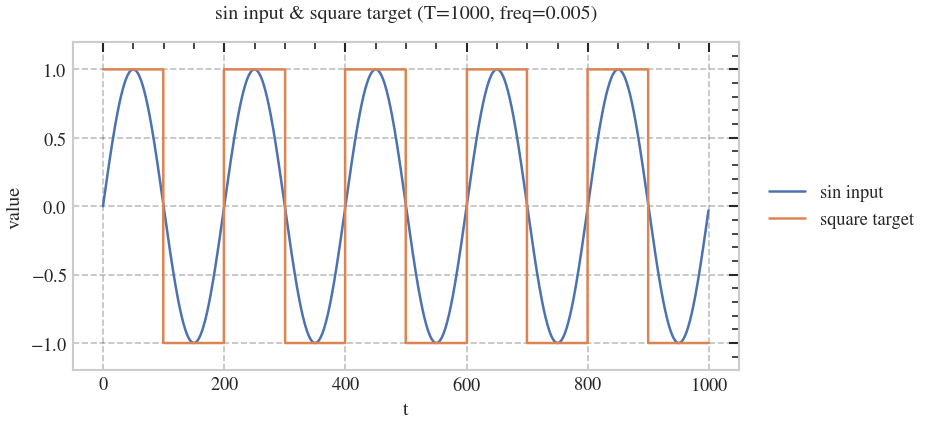

In [136]:
# 生成正弦-方波任务数据
def gen_sin_square(T, freq=0.005):
    """
    生成一个正弦输入，并给出对应的方波目标。
    freq 越小变化越慢。
    返回:
        u_sin: (T,) 正弦输入
        y_sq : (T,) 方波目标 ∈{-1, +1}
    """
    t = np.arange(T)
    u_sin = np.sin(2 * np.pi * freq * t)
    y_sq  = np.sign(u_sin)
    y_sq[y_sq == 0] = 1  # 避免 0
    return u_sin, y_sq

T, freq = 1000, 0.005
u_sin, y_sq = gen_sin_square(T, freq)
t = np.arange(T)

fig, ax = plt.subplots(figsize=(8, 3.8), dpi=120)

ax.plot(t, u_sin, label="sin input")
ax.step(t, y_sq, where="mid", label="square target")

ax.set_xlabel("t")
ax.set_ylabel("value")
ax.set_ylim(-1.2, 1.2)
ax.set_title(f"sin input & square target (T={T}, freq={freq})", pad=14)

ax.grid(True, alpha=0.25)
ax.legend(frameon=False, loc="center left", bbox_to_anchor=(1.02, 0.5))

fig.tight_layout()
plt.show()








2. 工具函数

In [137]:
# 数据归一化工具类
class MinMaxScaler:
    def __init__(self, feature_range=(-1, 1)):
        self.min_val = None
        self.max_val = None
        self.feature_range = feature_range

    def fit_transform(self, data):
        self.min_val = np.min(data)
        self.max_val = np.max(data)
        return self._transform(data)

    def transform(self, data):
        return self._transform(data)

    def _transform(self, data):
        data_std = (data - self.min_val) / (self.max_val - self.min_val)
        return data_std * (self.feature_range[1] - self.feature_range[0]) + self.feature_range[0]

    def inverse_transform(self, data):
        data_std = (data - self.feature_range[0]) / (self.feature_range[1] - self.feature_range[0])
        return data_std * (self.max_val - self.min_val) + self.min_val

In [138]:
# 计算归一化均方根误差 (NRMSE) 
def calc_nrmse(y_true, y_pred):
    """
    计算归一化均方根误差 (NRMSE)
    公式: RMSE / std(y_true)
    ESN作者Jagaer (2004) science中使用的归一化指标
    """
    if len(y_true) == 0: return np.inf
    mse = np.mean((y_true - y_pred) ** 2)
    rmse = np.sqrt(mse)
    sigma = np.std(y_true)
    
    if sigma < 1e-10: return rmse # 防止分母为0
    return rmse / sigma



3. 类脑拓扑矩阵生成

生成四种类脑拓扑结构和基线， 随机图， Watts-Strogatz小世界网络，模块化拓扑，分层模块化拓扑

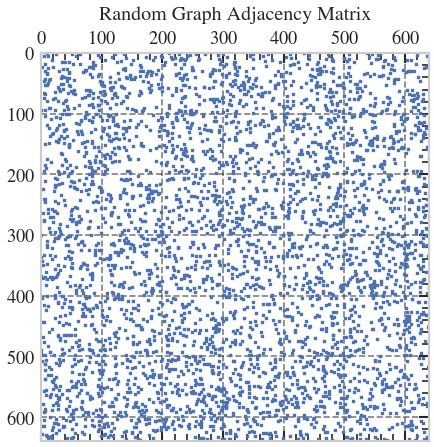

In [139]:
# 随机图
def make_adj_random(N, k_target, directed=True):
    p = k_target / (N - 1) # 连接概率
    G = nx.gnp_random_graph(N, p, directed=directed) # 生成随机图 
    A = nx.to_numpy_array(G, dtype=float) # 转换为numpy数组
    return A

# 可视化随机图的连接结构
A_random = make_adj_random(N, k_target)
plt.spy(A_random, markersize=1)
plt.title("Random Graph Adjacency Matrix")
plt.show()

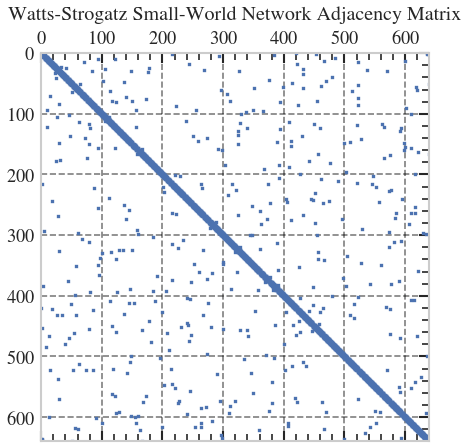

In [140]:
# 小世界网络 局部稠密 有少量长程连接
def make_adj_smallworld(N, k, beta=0.1): 
    assert k % 2 == 0, "Watts-Strogatz 的 k 通常需要是偶数。"
    G_undirected = nx.watts_strogatz_graph(N, k, beta) # 生成小世界网络 N个节点，平均度k，重连概率beta
    G = G_undirected.to_directed()
    A = nx.to_numpy_array(G, dtype=float) # 转换为numpy数组
    return A

# 可视化图的连接结构 
A_smallworld = make_adj_smallworld(N, k_target)
plt.spy(A_smallworld, markersize=1)
plt.title("Watts-Strogatz Small-World Network Adjacency Matrix")
plt.show()


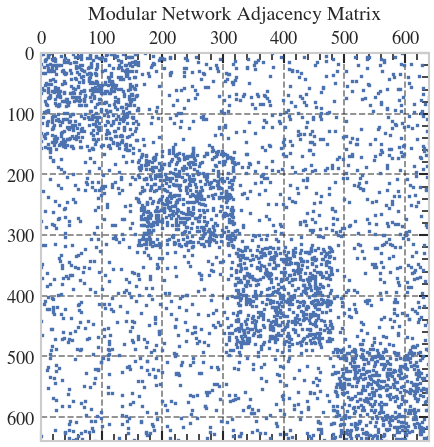

In [141]:
# 模块化图 模块之间连接稀疏 模块内部连接密集
# n_modules: 模块数量
# 暂时设定每个模块大小相等
def make_adj_modular(N, k_target, n_modules=4, ratio=5.0):
    """
    模块化图：通过求解 (p_in, p_out)，让平均 out-degree ≈ k_target。
    ratio = p_in / p_out 控制“模块内比模块间更稠密”的程度。
    """
    assert N % n_modules == 0, "为简化起见, N 应该能被 n_modules 整除。"
    size_per_module = N // n_modules
    sizes = [size_per_module] * n_modules

    n = size_per_module  # 每个模块的节点数
    n_in  = n - 1        # 同模块可选出边数 n-1是因为不能连自己 没有自环
    n_out = N - n        # 不同模块可选出边数 N-n是因为不能连自己 没有自环

    # 解 p_out, p_in 使得 E[out-degree] ≈ k_target
    p_out = k_target / (ratio * n_in + n_out)
    p_in  = ratio * p_out

    # 限制在 [0, 1]，避免极端情况
    p_in  = float(np.clip(p_in,  0.0, 1.0))
    p_out = float(np.clip(p_out, 0.0, 1.0))

    # 构建概率矩阵
    probs = [[p_in if i == j else p_out for j in range(n_modules)]
             for i in range(n_modules)]

    G = nx.stochastic_block_model(sizes, probs, directed=True) # 生成模块化图
    A = nx.to_numpy_array(G, dtype=float)

    return A

# 可视化图的连接结构
A_modular = make_adj_modular(N, k_target)
plt.spy(A_modular, markersize=1)
plt.title("Modular Network Adjacency Matrix")
plt.show()


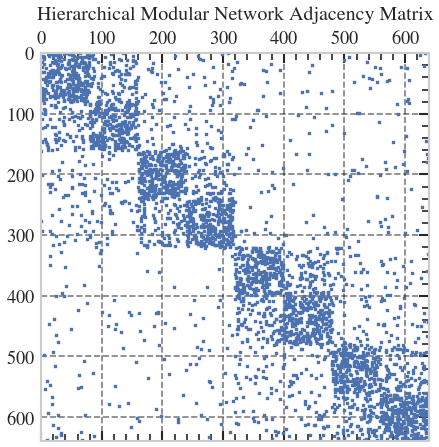

In [142]:
# 分层模块化拓扑（hierarchical modular）
def make_adj_hierarchical(
    N,
    k_target,
    n_modules_lvl1=8,   # 一级模块数，对应论文里的 8 个模块
    L=4,                # 总层数（含最顶层整网）
    r=0.3,              # 层级缩放因子 p_l = r^{l-1} p1
    p1=0.5,             # 一级模块内的连边概率
    directed=True,
):
    """
    复刻论文的分层模块化拓扑（hierarchical modular network）：
    - N: reservoir 神经元数
    - k_target: 目标平均出度
    - n_modules_lvl1: 一级模块数量（论文默认 8）
    - L: 层数（论文默认 4）
    - r, p1: 控制各层连边概率，p_l = r^{l-1} * p1
    """

    # 为了完全对齐论文的 8×50 结构，推荐 N=400。
    assert N % n_modules_lvl1 == 0, "N 必须能被 n_modules_lvl1 整除（例如 N=400, n_modules_lvl1=8）"
    size_per_module = N // n_modules_lvl1

    M1 = n_modules_lvl1
    n1 = size_per_module

    # ----- 1. 各层连边概率 p_l -----
    p_levels = [p1 * (r ** (l - 1)) for l in range(1, L + 1)]  # [p1, p2, ..., pL]

    # P[a,b]：一级模块 a -> 一级模块 b 的连边概率
    P = np.zeros((M1, M1), dtype=float)
    # level 1：对角块 p1
    np.fill_diagonal(P, p_levels[0])

    # level 2~L：依次在更大的块里填更小的概率（只填还为 0 的位置）
    block_size = 1  # 以“一级模块”为单位的块大小
    for level in range(2, L + 1):
        g = 2   # 每一层把两个低层模块并成一个高层模块
        block_size *= g
        p_l = p_levels[level - 1]
        for start in range(0, M1, block_size):
            end = start + block_size
            for i in range(start, end):
                for j in range(start, end):
                    if i == j:
                        continue
                    if P[i, j] == 0:
                        P[i, j] = p_l

    # ----- 2. 计算“基准”期望出度，再整体缩放到 k_target -----
    # 由于所有一级模块对称，只用算 module 0 的一行即可
    a = 0
    expected_k_base = 0.0
    for b in range(M1):
        if b == a:
            # 同一模块：节点数 n1，排除自己，所以 (n1 - 1)
            expected_k_base += (n1 - 1) * P[a, b]
        else:
            # 其他模块：整块 n1 个节点
            expected_k_base += n1 * P[a, b]

    scale = 1.0
    if expected_k_base > 0:
        scale = min(1.0, k_target / expected_k_base)
        P = P * scale  # 保持层级结构不变，只是整体变稀疏/稠密一点

    # ----- 3. 根据 P 逐点采样邻接矩阵 -----
    A = np.zeros((N, N), dtype=float)
    # module_assign[i] 表示第 i 个节点属于哪个一级模块
    module_assign = np.repeat(np.arange(M1), n1)

    for i in range(N):
        mi = module_assign[i]
        prob_row = P[mi, module_assign].copy()

        # 禁止自环
        prob_row[i] = 0.0

        if directed:
            rand = np.random.rand(N)
            mask = rand < prob_row
            A[i, mask] = 1.0
        else:
            # 无向版：只采上三角，再对称
            for j in range(i + 1, N):
                if np.random.rand() < prob_row[j]:
                    A[i, j] = 1.0
                    A[j, i] = 1.0

    return A

A_hier = make_adj_hierarchical(N, k_target)

plt.spy(A_hier, markersize=1)
plt.title("Hierarchical Modular Network Adjacency Matrix")
plt.show()


In [143]:
# ====== 检查平均出度是不是都 ≈ k_target ======
# 因为生成的结构是随机的，实际平均出度会有波动
A_random = make_adj_random(N, k_target)
print("random   k_eff =", A_random.sum(axis=1).mean())

A_small  = make_adj_smallworld(N, k_target, beta=0.1)
print("smallworld k_eff =", A_small.sum(axis=1).mean())

A_mod    = make_adj_modular(N, k_target, n_modules=4)
print("modular  k_eff =", A_mod.sum(axis=1).mean())

A_hier   = make_adj_hierarchical(N, k_target)
print("heir k_eff =", A_hier.sum(axis=1).mean())
# =============================================


random   k_eff = 5.9296875
smallworld k_eff = 6.0
modular  k_eff = 5.928125
heir k_eff = 6.0203125


4. reservoir动力学

In [144]:
# 谱半径缩放函数
# 谱半径 ρ (spectral radius) 是矩阵特征值的最大模值，反映了系统动力学的稳定性和记忆能力
# ρ 小 → 状态快速收缩，记忆短
# ρ 适中 → 临界状态（critical state），良好记忆
# ρ 大 → 快速进入混沌，可能不稳定

def make_W_res(adj, rho_target):
    N = adj.shape[0]
    W_raw = np.random.randn(N, N) * adj 

    eigvals = np.linalg.eigvals(W_raw) 
    sr = np.max(np.abs(eigvals)) # 计算谱半径 最大模值 = 谱半径 
    if sr == 0:
        return W_raw

    W_res = (rho_target / sr) * W_raw # 缩放权重矩阵以达到目标谱半径 在rho_target中进行调节修改目标

 

    return W_res

In [145]:
# 简单reservoir动力学
# reservoir结构： reservoir权重矩阵W_res 输入权重矩阵W_in 
# u_seq：输入序列 washout：洗牌时间步长（消除初始状态影响）
# N = reservoir大小，T = 输入序列长度, x = reservoir状态, X_all = 所有时间步的reservoir状态记录
# 返回有效的reservoir状态矩阵X（去除洗牌部分），输入序列经过输入权重矩阵，再经过reservoir权重矩阵，最后通过tanh激活函数更新状态
def run_reservoir(W_res, W_in, u_seq, washout): 
    N = W_res.shape[0] 
    T = len(u_seq)
    x = np.zeros(N)
    X_all = np.zeros((T, N))

    for t in range(T):
        x = np.tanh(W_res @ x + W_in * u_seq[t]) # 更新reservoir状态
        X_all[t] = x

    X = X_all[washout:]
    return X

5. 神经网络训练

In [146]:
# 使用岭回归训练读出层
def train_readout_ridge(X, y, reg=REG):
    X = np.asarray(X, dtype=np.float64)
    y = np.asarray(y, dtype=np.float64)

    # --- 检查传进来的 X 和 y 有没有 NaN/Inf ---
    if not np.all(np.isfinite(X)):
        idx = np.argwhere(~np.isfinite(X))[0]
        raise FloatingPointError(
            f"X has NaN/Inf, first bad at (t={idx[0]}, n={idx[1]}). "
            f"min={np.nanmin(X)}, max={np.nanmax(X)}"
        )
    if not np.all(np.isfinite(y)):
        idx = np.argwhere(~np.isfinite(y))[0]
        raise FloatingPointError(
            f"y has NaN/Inf, first bad at (t={idx[0]}). "
            f"min={np.nanmin(y)}, max={np.nanmax(y)}"
        )

    T, N = X.shape
    X_aug = np.hstack([X, np.ones((T, 1))])

    # --- 再检查一次增广矩阵 ---
    if not np.all(np.isfinite(X_aug)):
        idx = np.argwhere(~np.isfinite(X_aug))[0]
        raise FloatingPointError(
            f"X_aug has NaN/Inf, first bad at (t={idx[0]}, col={idx[1]})."
        )

    # 岭回归解析解: W = (X^T X + reg * I)^-1 X^T y
    XtX = np.einsum('ti,tj->ij', X_aug, X_aug)
    I = np.eye(XtX.shape[0])
    I[-1, -1] = 0

    Xty = np.einsum('ti,t->i', X_aug, y)
    w_aug = np.linalg.solve(XtX + reg * I, Xty)

    w = w_aug[:-1]
    b = w_aug[-1]
    return w, b
  

# 标准评测流程: Washout -> Free Run (Horizon步) -> NRMSE
def evaluate_horizon_nrmse(W_res, W_in, w_out, b_out, 
                           mg_test_scaled, 
                           washout=T_washout, horizon=HORIZON):
    """
    标准评测流程: Washout -> Free Run (Horizon步) -> NRMSE
    """
    N = W_res.shape[0]
    
    # 1. Washout
    x = np.zeros(N)
    for t in range(washout):
        u_t = mg_test_scaled[t]
        x = np.tanh(W_res @ x + W_in * u_t)
        
    # 2. 自由预测 (Free-run)
    preds = []
    u_t = mg_test_scaled[washout] # 起始输入
    
    for _ in range(horizon):
        x = np.tanh(W_res @ x + W_in * u_t) # 更新状态
        y_hat = w_out @ x + b_out           # 预测输出
        preds.append(y_hat)
        u_t = y_hat                         # 反馈输入
        
    preds = np.array(preds)
    
    # 3. 对齐真实值 (Washout 之后的 Horizon 步)
    y_true = mg_test_scaled[washout + 1 : washout + 1 + horizon]
    
    return calc_nrmse(y_true, preds)

6. 任务启动：单任务为Mackey-Glass 预测任务；多任务为Mackey-Glass 预测 和 正弦->方波任务 同时进行

MG  预测任务封装与运行

In [147]:
# 封装 MG 任务
def run_task_mg(W_res, W_in,
                T_train, T_test,
                washout=T_washout, horizon=HORIZON, reg=REG):
    """
    用你现在的 MG 逻辑封装成一个任务。
    """
    # ===== 数据生成与归一化（ =====
    total_len = T_train + T_test + 1000  # 预留一些冗余
    mg_full = generate_mackey_glass(total_len)

    # 划分数据集
    train_raw = mg_full[:T_train]
    test_raw  = mg_full[T_train:]

    # 归一化
    scaler = MinMaxScaler(feature_range=(-1, 1))
    train_data = scaler.fit_transform(train_raw)
    test_data  = scaler.transform(test_raw)

    # 训练 (Teacher Forcing)
    u_train = train_data[:-1]
    y_train = train_data[1:]

    # reservoir 状态
    X_train = run_reservoir(W_res, W_in, u_train, washout=washout)
    y_train_eff = y_train[washout:]

    # 训练读出层
    w_out, b_out = train_readout_ridge(X_train, y_train_eff, reg=reg)

    # 测试 + 自由预测 N 步
    nrmse = evaluate_horizon_nrmse(
        W_res, W_in, w_out, b_out,
        test_data,
        washout=washout,
        horizon=horizon
    )

    return nrmse


正弦-方波任务封装与运行（已搁置）

In [148]:
# 该任务取自Milisav et al., 2025, 用于测试多任务学习能力
# 正弦->方波任务封装
def evaluate_sin_square(W_res, W_in, w_out, b_out,
                        u_test, y_test,
                        washout=T_washout):
    """
    正弦 -> 方波 的 one-step 回归，用 R^2 作为指标。
    """

    X_test = run_reservoir(W_res, W_in, u_test, washout=0)

    # 对齐 washout
    X_eff = X_test[washout:]
    y_true = y_test[washout:]

    # 预测
    y_hat = X_eff @ w_out + b_out

    # R^2
    ss_res = np.sum((y_true - y_hat) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    r2 = 1.0 - ss_res / ss_tot

    return r2, y_hat, y_true

# 运行正弦->方波任务
def run_task_sin_square(W_res, W_in,
                        T_train, T_test,
                        washout=T_washout, reg=REG):
    """
    在给定 W_res, W_in 上跑 正弦->方波 任务。
    返回:
        r2: R^2 指标
    """
    # 生成训练/测试数据
    u_train, y_train = gen_sin_square(T_train, freq=0.005)
    u_test,  y_test  = gen_sin_square(T_test,  freq=0.005)

    # 训练读出：run_reservoir 需要显式 washout
    X_train = run_reservoir(W_res, W_in, u_train, washout=washout)
    y_train_eff = y_train[washout:]
    w_out, b_out = train_readout_ridge(X_train, y_train_eff, reg=reg)

    # 测试
    r2, _, _ = evaluate_sin_square(
        W_res, W_in, w_out, b_out,
        u_test, y_test,
        washout=washout
    )
    return r2

In [149]:
# 跑单任务：Mackey-Glass 预测任务
def run_single_condition_v2(topology, rho, seed):
    np.random.seed(seed)

    # ===== 拓扑生成 =====
    if topology == "random":
        adj = make_adj_random(N, k_target)
    elif topology == "smallworld":
        adj = make_adj_smallworld(N, k=k_target, beta=0.1)
    elif topology == "modular":
        adj = make_adj_modular(N, k_target, n_modules=4)
    elif topology == "hierarchical":
        adj = make_adj_hierarchical(N = N, k_target = k_target)
    else:
        raise ValueError(f"Unknown topology: {topology}")
    
    # ===== 生成 reservoir 权重 =====
    W_res = make_W_res(adj, rho_target=rho)
    W_in  = np.random.randn(N) * W_in_scale

    # ===== 单任务：MG 预测 =====
    nrmse = run_task_mg(
        W_res, W_in,
        T_train=T_train,
        T_test=T_test,
        washout=T_washout,
        horizon=HORIZON,
        reg=REG
    )

    return nrmse


In [ ]:
# 跑多任务：Mackey-Glass 预测 + 正弦->方波 #已搁置
def run_single_condition_v2_multitask(topology, rho, seed,
                                      T_train_sin=3000, T_test_sin=3000):
    """
    多任务版：
        Task1 = MG 预测（nrmse）
        Task2 = 正弦->方波（R^2）
    在同一个 reservoir (W_res, W_in) 上跑两个任务，返回 dict.
    """
    np.random.seed(seed)

   
    if topology == "random":
        adj = make_adj_random(N, k_target)
    elif topology == "smallworld":
        adj = make_adj_smallworld(N, k=k_target, beta=0.1)
    elif topology == "modular":
        adj = make_adj_modular(N, k_target, n_modules=4)
    elif topology == "hierarchical":
        adj = make_adj_hierarchical(N, k_target = k_target)
    else:
        raise ValueError(f"Unknown topology: {topology}")

    # ===== 同一套 reservoir 权重 =====
    W_res = make_W_res(adj, rho_target=rho)
    W_in  = np.random.randn(N) * W_in_scale

    # ===== Task1: MG =====
    
    nrmse_mg = run_task_mg(
        W_res, W_in,
        T_train=T_train,
        T_test=T_test,
        washout=T_washout,
        horizon=HORIZON,
        reg=REG
    )

    # ===== Task2: 正弦->方波 =====
    r2_sin = run_task_sin_square(
        W_res, W_in,
        T_train=T_train_sin,
        T_test=T_test_sin,
        washout=T_washout,
        reg=REG
    )

    return {
        "mg_nrmse": nrmse_mg,
        "sin_r2":   r2_sin
    }


7. 任务结果可视化

In [ ]:

# 多任务可视化 已搁置
def plot_multi_task_summary(
    results_multi,
    RHO_list,
    topologies,
    band="sem",          # "std" | "sem" | "ci95"
    band_scale=1.0,
    alpha_band=0.15,
    mg_ylim=None,        # e.g. (0, 1.5)
    r2_ylim=(-0.2, 1.05)
):
    mg_dict  = results_multi["mg_nrmse"]
    sin_dict = results_multi["sin_r2"]

    def _band(sd, n):
        if band == "std":
            w = sd
        elif band == "sem":
            w = sd / np.sqrt(np.maximum(n, 1))
        elif band == "ci95":
            w = 1.96 * (sd / np.sqrt(np.maximum(n, 1)))
        else:
            raise ValueError("band must be one of: 'std', 'sem', 'ci95'")
        return band_scale * w

    def _stats(task_dict, topo):
        xs, mu, sd, n = [], [], [], []
        for rho in RHO_list:
            arr = np.asarray(task_dict[topo][rho], dtype=float)
            xs.append(rho)
            mu.append(arr.mean())
            sd.append(arr.std(ddof=0))
            n.append(len(arr))
        return np.array(xs), np.array(mu), np.array(sd), np.array(n)

    def _style(ax, ylabel, title):
        ax.set_title(title, pad=10)
        ax.set_xlabel(r"Spectral radius $\rho$")
        ax.set_ylabel(ylabel)
        ax.set_axisbelow(True)
        ax.grid(True, alpha=0.25)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    # --------- Figure 1: MG NRMSE ----------
    fig, ax = plt.subplots(figsize=(7.6, 4.2), dpi=120)
    for topo in topologies:
        xs, mu, sd, n = _stats(mg_dict, topo)
        w = _band(sd, n)
        ax.plot(xs, mu, marker="o", markersize=4, label=topo)
        ax.fill_between(xs, mu - w, mu + w, alpha=alpha_band)

    _style(ax, "Free-run NRMSE", f"MG free-run NRMSE vs. rho")
    if mg_ylim is not None:
        ax.set_ylim(*mg_ylim)

    ax.set_xticks(RHO_list)
    ax.set_xticklabels([f"{rho:.2f}" for rho in RHO_list], rotation=45, ha="right")
    ax.legend(frameon=False, loc="center left", bbox_to_anchor=(1.02, 0.5))
    fig.tight_layout()
    plt.show()

    # --------- Figure 2: Sin->Square R2 ----------
    fig, ax = plt.subplots(figsize=(7.6, 4.2), dpi=120)
    for topo in topologies:
        xs, mu, sd, n = _stats(sin_dict, topo)
        w = _band(sd, n)
        ax.plot(xs, mu, marker="o", markersize=4, label=topo)
        ax.fill_between(xs, mu - w, mu + w, alpha=alpha_band)

    _style(ax, r"$R^2$", f"Sin→Square $R^2$ vs. rho ")
    if r2_ylim is not None:
        ax.set_ylim(*r2_ylim)

    ax.set_xticks(RHO_list)
    ax.set_xticklabels([f"{rho:.2f}" for rho in RHO_list], rotation=45, ha="right")
    ax.legend(frameon=False, loc="center left", bbox_to_anchor=(1.02, 0.5))
    fig.tight_layout()
    plt.show()



In [152]:
# 单任务可视化

def plot_nrmse_two_views(
    results, RHO_list, topologies,
    y_max=1.5,
    band="sem",          
    band_scale=1.0,     
    alpha_band=0.15
):
    def _stats(topo, rhos_subset):
        xs, mu, sd, n = [], [], [], []
        for rho in rhos_subset:
            arr = np.asarray(results[topo][rho], dtype=float)
            xs.append(rho)
            mu.append(arr.mean())
            sd.append(arr.std(ddof=0))
            n.append(len(arr))
        return np.array(xs), np.array(mu), np.array(sd), np.array(n)

    def _band(sd, n):
        # 返回每个点的“带宽”（同形状数组）
        if band == "std":
            w = sd
        elif band == "sem":
            w = sd / np.sqrt(np.maximum(n, 1))
        elif band == "ci95":
            w = 1.96 * (sd / np.sqrt(np.maximum(n, 1)))
        else:
            raise ValueError("band must be one of: 'std', 'sem', 'ci95'")
        return band_scale * w

    def _style(ax, title, logy=False):
        ax.set_title(title, pad=10)
        ax.set_xlabel(r"Spectral radius $\rho$")
        ax.set_axisbelow(True)
        ax.grid(True, alpha=0.25)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        if logy:
            ax.set_ylabel("Free-run NRMSE (log scale)")
            ax.set_yscale("log")
            ax.grid(True, which="both", alpha=0.22)
            ax.yaxis.set_minor_locator(mticker.LogLocator(base=10, subs=np.arange(2, 10) * 0.1))
            ax.yaxis.set_minor_formatter(mticker.NullFormatter())
        else:
            ax.set_ylabel("Free-run NRMSE")

    # ---------- 图 1：rho <= 1.0 ----------
    rhos_1 = [rho for rho in RHO_list if rho <= 1.0]
    fig, ax = plt.subplots(figsize=(7.6, 4.2), dpi=120)

    for topo in topologies:
        xs, mu, sd, n = _stats(topo, rhos_1)
        w = _band(sd, n)
        ax.plot(xs, mu, marker="o", markersize=4, label=topo)
        ax.fill_between(xs, mu - w, mu + w, alpha=alpha_band)

    _style(ax, f"Free-run NRMSE vs. spectral radius (rho ≤ 1.0)  | band={band}", logy=False)
    ax.set_ylim(0.0, y_max)
    ax.legend(frameon=False, loc="center left", bbox_to_anchor=(1.02, 0.5))
    fig.tight_layout()
    plt.show()

    # ---------- 图 2：所有 rho，log-y ----------
    rhos_all = list(RHO_list)
    fig, ax = plt.subplots(figsize=(7.6, 4.2), dpi=120)

    for topo in topologies:
        xs, mu, sd, n = _stats(topo, rhos_all)
        w = _band(sd, n)

        mu_clip = np.clip(mu, 1e-12, None)
        lower = np.clip(mu - w, 1e-12, None)
        upper = np.clip(mu + w, 1e-12, None)

        ax.plot(xs, mu_clip, marker="o", markersize=4, label=topo)
        ax.fill_between(xs, lower, upper, alpha=alpha_band)

    _style(ax, r"Free-run NRMSE vs. spectral radius (all $\rho$, log-y)", logy=True)
    ax.set_xticks(rhos_all)
    ax.set_xticklabels([f"{rho:.2f}" for rho in rhos_all], rotation=45, ha="right")
    ax.legend(frameon=False, loc="center left", bbox_to_anchor=(1.02, 0.5))
    fig.tight_layout()
    plt.show()



8. 主实验循环

In [153]:


# 主实验循环
def main():
    topologies = ["random", "smallworld", "modular","hierarchical"]

    if not MULTI_TASK:
        # ===== 原来的单任务逻辑 =====
        results = {top: {rho: [] for rho in RHO_list} for top in topologies}

        for top in topologies:
            for rho in RHO_list:
                for s in range(N_seed): # 不同随机种子
                    mse_free = run_single_condition_v2(top, rho, seed=1000 + s)
                    results[top][rho].append(mse_free)
                    print(f"[SINGLE][{top}] rho={rho:.2f}, seed={s}, free-run nrmse={mse_free:.4e}")

        print("\n=== Free-run nrmse ===")
        for top in topologies:
            print(f"Topology: {top}")
            for rho in RHO_list:
                arr = np.array(results[top][rho])
                mean = arr.mean()
                std  = arr.std()
                print(f"  rho={rho:.2f} -> free-run nrmse = {mean:.4e} ± {std:.4e}")
            print()

        return results

    else:
        # ===== 多任务逻辑：同时记录 MG 和 sin-square =====
        results_multi = {
            "mg_nrmse": {top: {rho: [] for rho in RHO_list} for top in topologies},
            "sin_r2":   {top: {rho: [] for rho in RHO_list} for top in topologies},
        }

        for top in topologies:
            for rho in RHO_list:
                for s in range(N_seed):
                    metrics = run_single_condition_v2_multitask(top, rho, seed=1000 + s)
                    results_multi["mg_nrmse"][top][rho].append(metrics["mg_nrmse"])
                    results_multi["sin_r2"][top][rho].append(metrics["sin_r2"])
                    print(
                        f"[MULTI][{top}] rho={rho:.2f}, seed={s}, "
                        f"mg_nrmse={metrics['mg_nrmse']:.4e}, sin_r2={metrics['sin_r2']:.4f}"
                    )

        print("\n=== Multitask results (MG + sin->square) ===")
        for top in topologies:
            print(f"Topology: {top}")
            for rho in RHO_list:
                arr_mg  = np.array(results_multi["mg_nrmse"][top][rho])
                arr_sin = np.array(results_multi["sin_r2"][top][rho])
                print(
                    f"  rho={rho:.2f} -> "
                    f"MG nrmse = {arr_mg.mean():.4e} ± {arr_mg.std():.4e}, "
                    f"sin R^2 = {arr_sin.mean():.4f} ± {arr_sin.std():.4f}"
                )
            print()

        return results_multi


[MULTI][random] rho=0.60, seed=0, mg_nrmse=6.9030e-01, sin_r2=0.9349
[MULTI][random] rho=0.60, seed=1, mg_nrmse=9.4609e-01, sin_r2=0.9345
[MULTI][random] rho=0.60, seed=2, mg_nrmse=7.3144e-01, sin_r2=0.9340
[MULTI][random] rho=0.60, seed=3, mg_nrmse=6.6927e-01, sin_r2=0.9349
[MULTI][random] rho=0.60, seed=4, mg_nrmse=8.2670e-01, sin_r2=0.9337
[MULTI][random] rho=0.60, seed=5, mg_nrmse=7.6200e-01, sin_r2=0.9335
[MULTI][random] rho=0.60, seed=6, mg_nrmse=6.7776e-01, sin_r2=0.9339
[MULTI][random] rho=0.60, seed=7, mg_nrmse=7.2762e-01, sin_r2=0.9320
[MULTI][random] rho=0.60, seed=8, mg_nrmse=7.5671e-01, sin_r2=0.9340
[MULTI][random] rho=0.60, seed=9, mg_nrmse=7.5293e-01, sin_r2=0.9337
[MULTI][random] rho=0.70, seed=0, mg_nrmse=1.3375e+01, sin_r2=0.9387
[MULTI][random] rho=0.70, seed=1, mg_nrmse=2.7282e-01, sin_r2=0.9346
[MULTI][random] rho=0.70, seed=2, mg_nrmse=8.0417e-01, sin_r2=0.9324
[MULTI][random] rho=0.70, seed=3, mg_nrmse=9.3679e-01, sin_r2=0.9354
[MULTI][random] rho=0.70, seed=4, 

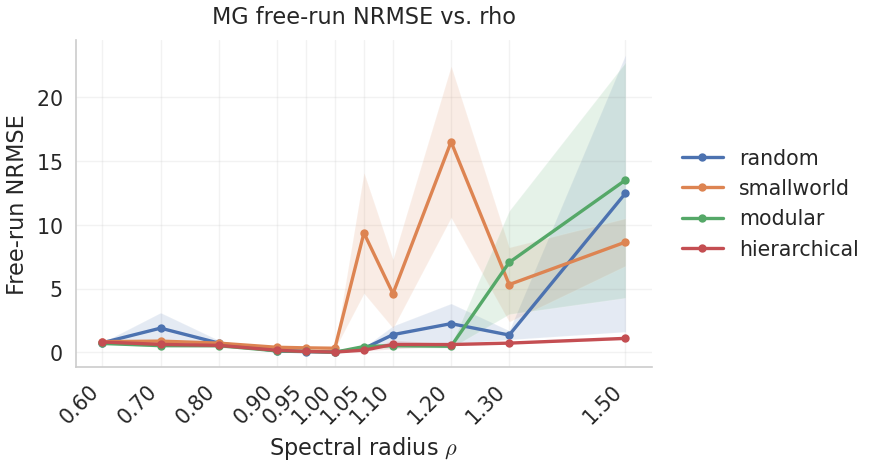

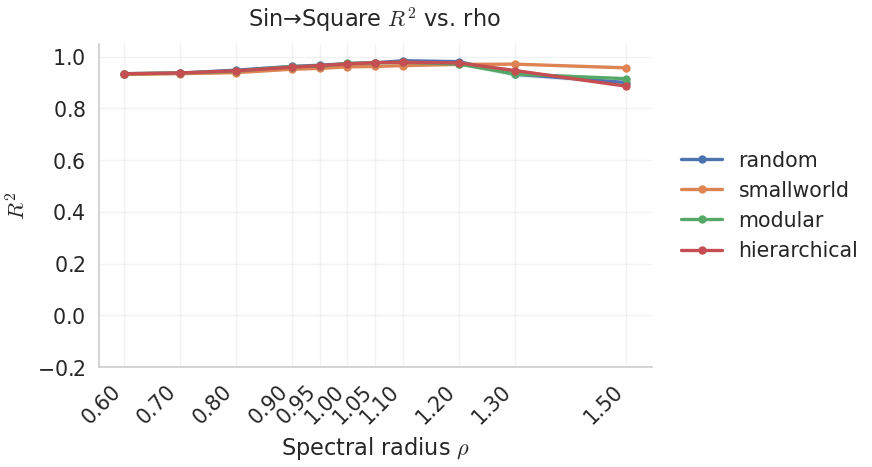

In [154]:

if __name__ == "__main__":
    # 可视化参数
    sns.set_context("paper", font_scale=1.4)
    sns.set_style("whitegrid")
    plt.rcParams['axes.unicode_minus'] = False   # 解决负号显示问题
    plt.rcParams['lines.linewidth'] = 2.0
    #  results 
    np.seterr(invalid="raise", over="raise", divide="raise") # 设置NumPy错误处理，遇到无效操作、溢出或除以零时抛出异常
    results = main() 
    # 多任务可视化
    if MULTI_TASK:
        topologies = list(results["mg_nrmse"].keys())
        plot_multi_task_summary(results, RHO_list, topologies, band="sem")
    else:
        topologies = list(results.keys())
        plot_nrmse_two_views(results, RHO_list, topologies)


In [155]:
def report_mean_and_edge_of_chaos(results, RHO_list, rho_edge=1.0, topologies=None):
    # --- detect single vs multi ---
    is_multi = isinstance(results, dict) and ("mg_nrmse" in results) and ("sin_r2" in results)

    if is_multi:
        mg_dict  = results["mg_nrmse"]
        sin_dict = results["sin_r2"]
        if topologies is None:
            topologies = list(mg_dict.keys())
    else:
        if topologies is None:
            topologies = list(results.keys())

    # --- choose "edge of chaos" rho (closest to 1.0 by default) ---
    rho_edge = float(rho_edge)
    rho_eoc = min(RHO_list, key=lambda r: abs(float(r) - rho_edge))

    def _mean_std(arr_list):
        arr = np.asarray(arr_list, dtype=float)
        return float(arr.mean()), float(arr.std(ddof=0)), int(arr.size)

    def _best_rho(metric_means, mode):
        # mode: "min" or "max"
        if mode == "min":
            idx = int(np.argmin(metric_means))
        else:
            idx = int(np.argmax(metric_means))
        return idx

    print(f"[Edge-of-chaos rho] target={rho_edge:.2f} -> used rho_eoc={rho_eoc:.2f}\n")

    if not is_multi:
        # -------- single-task: MG only (NRMSE lower is better) --------
        print("=== Single-task (MG free-run NRMSE; lower is better) ===")
        for topo in topologies:
            means = []
            stds  = []
            ns    = []
            for rho in RHO_list:
                mu, sd, n = _mean_std(results[topo][rho])
                means.append(mu); stds.append(sd); ns.append(n)

            means = np.asarray(means)
            best_idx = _best_rho(means, mode="min")
            rho_best = float(RHO_list[best_idx])

            mu_best, sd_best, n_best = _mean_std(results[topo][rho_best])
            mu_eoc,  sd_eoc,  n_eoc  = _mean_std(results[topo][rho_eoc])

            print(f"[{topo}]")
            print(f"  BEST : rho={rho_best:.2f} | mean={mu_best:.6f} ± {sd_best:.6f} (n={n_best})")
            print(f"  EoC  : rho={rho_eoc:.2f} | mean={mu_eoc :.6f} ± {sd_eoc :.6f} (n={n_eoc})")
        return

    # -------- multi-task: MG NRMSE (min) and SIN R2 (max) --------
    print("=== Multi-task ===")
    print("Task A: MG free-run NRMSE (lower is better)")
    for topo in topologies:
        means = []
        for rho in RHO_list:
            mu, sd, n = _mean_std(mg_dict[topo][rho])
            means.append(mu)
        means = np.asarray(means)
        best_idx = _best_rho(means, mode="min")
        rho_best = float(RHO_list[best_idx])

        mu_best, sd_best, n_best = _mean_std(mg_dict[topo][rho_best])
        mu_eoc,  sd_eoc,  n_eoc  = _mean_std(mg_dict[topo][rho_eoc])

        print(f"[{topo}]")
        print(f"  BEST : rho={rho_best:.2f} | mean={mu_best:.6f} ± {sd_best:.6f} (n={n_best})")
        print(f"  EoC  : rho={rho_eoc:.2f} | mean={mu_eoc :.6f} ± {sd_eoc :.6f} (n={n_eoc})")

    print("\nTask B: Sin→Square R² (higher is better)")
    for topo in topologies:
        means = []
        for rho in RHO_list:
            mu, sd, n = _mean_std(sin_dict[topo][rho])
            means.append(mu)
        means = np.asarray(means)
        best_idx = _best_rho(means, mode="max")
        rho_best = float(RHO_list[best_idx])

        mu_best, sd_best, n_best = _mean_std(sin_dict[topo][rho_best])
        mu_eoc,  sd_eoc,  n_eoc  = _mean_std(sin_dict[topo][rho_eoc])

        print(f"[{topo}]")
        print(f"  BEST : rho={rho_best:.2f} | mean={mu_best:.6f} ± {sd_best:.6f} (n={n_best})")
        print(f"  EoC  : rho={rho_eoc:.2f} | mean={mu_eoc :.6f} ± {sd_eoc :.6f} (n={n_eoc})")

In [156]:
report_mean_and_edge_of_chaos(results, RHO_list)

[Edge-of-chaos rho] target=1.00 -> used rho_eoc=1.00

=== Multi-task ===
Task A: MG free-run NRMSE (lower is better)
[random]
  BEST : rho=1.00 | mean=0.015557 ± 0.014991 (n=10)
  EoC  : rho=1.00 | mean=0.015557 ± 0.014991 (n=10)
[smallworld]
  BEST : rho=1.00 | mean=0.321846 ± 0.184658 (n=10)
  EoC  : rho=1.00 | mean=0.321846 ± 0.184658 (n=10)
[modular]
  BEST : rho=1.00 | mean=0.010910 ± 0.005986 (n=10)
  EoC  : rho=1.00 | mean=0.010910 ± 0.005986 (n=10)
[hierarchical]
  BEST : rho=1.00 | mean=0.023113 ± 0.021026 (n=10)
  EoC  : rho=1.00 | mean=0.023113 ± 0.021026 (n=10)

Task B: Sin→Square R² (higher is better)
[random]
  BEST : rho=1.10 | mean=0.983904 ± 0.006259 (n=10)
  EoC  : rho=1.00 | mean=0.972978 ± 0.004366 (n=10)
[smallworld]
  BEST : rho=1.30 | mean=0.970764 ± 0.006745 (n=10)
  EoC  : rho=1.00 | mean=0.960334 ± 0.004865 (n=10)
[modular]
  BEST : rho=1.10 | mean=0.977655 ± 0.003741 (n=10)
  EoC  : rho=1.00 | mean=0.973530 ± 0.003867 (n=10)
[hierarchical]
  BEST : rho=1.10 |